<a href="https://colab.research.google.com/github/Zahab163/ML-housing-price-predictor/blob/main/California_Housing_Prices_Analysis_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicting Housing Prices  using Machine Learning Models:

In [ ]:
#Importing Libraries which are needed in the Process
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

 #EDA (Exploratory Data Analysis)

 ##Uploading the Housing Dataset:

 First we created a file for csv files cause their are two California_housing sets in sample_data , one for test and the other for train ..In order we don't miss any details in dataset so, we fetched both cause we could do so.

In [ ]:

# Uploaded the housing prices file which needs data cleaning

file_df =['/content/sample_data/california_housing_train.csv','/content/sample_data/california_housing_test.csv']

# We combined both csv file within one data frame
housing_df = pd.concat((pd.read_csv(f, sep=',') for f in file_df))


In [ ]:
# Display data frame
housing_df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0


In [ ]:
# Taking Information
housing_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20000 entries, 0 to 2999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20000 non-null  float64
 1   latitude            20000 non-null  float64
 2   housing_median_age  20000 non-null  float64
 3   total_rooms         20000 non-null  float64
 4   total_bedrooms      20000 non-null  float64
 5   population          20000 non-null  float64
 6   households          20000 non-null  float64
 7   median_income       20000 non-null  float64
 8   median_house_value  20000 non-null  float64
dtypes: float64(9)
memory usage: 1.5 MB


Luckily, we do'nt have any null values here and our data type is not Object which is good for creating ML model. but if there would be any null value in dataset we could simply check it by droping them .

In [ ]:
## Running the code for satisfaction and checking the lenght
housing_df = housing_df.dropna()
len(housing_df)

20000

We are spliting our data set into three sets train_pd, test_pd and val_pd, to reduce errors in our data set .we want to see that how well our model has done? if we have to choose which model is going well with our data set cause we have to choose that which has low test error but than we run out of data so we split it into

In [ ]:
#spliting data
train_pd, test_pd, val_pd = housing_df[:17000], housing_df[17000:18500], housing_df[18500:]
len(train_pd), len(test_pd), len(val_pd)

(17000, 1500, 1500)

In [ ]:
# we are spliting data into x ,y
x_train, y_train =train_pd.to_numpy()[:,:-1] , train_pd.to_numpy()[:,-1]
x_train, y_train

(array([[-114.31  ,   34.19  ,   15.    , ..., 1015.    ,  472.    ,
            1.4936],
        [-114.47  ,   34.4   ,   19.    , ..., 1129.    ,  463.    ,
            1.82  ],
        [-114.56  ,   33.69  ,   17.    , ...,  333.    ,  117.    ,
            1.6509],
        ...,
        [-124.3   ,   41.84  ,   17.    , ..., 1244.    ,  456.    ,
            3.0313],
        [-124.3   ,   41.8   ,   19.    , ..., 1298.    ,  478.    ,
            1.9797],
        [-124.35  ,   40.54  ,   52.    , ...,  806.    ,  270.    ,
            3.0147]]),
 array([ 66900.,  80100.,  85700., ..., 103600.,  85800.,  94600.]))

In [ ]:
#to see how many columns and they have 8 values as seen in the output
x_train.shape, y_train.shape

((17000, 8), (17000,))

In [ ]:
 #same as for val and test
 x_val, y_val = val_pd.to_numpy()[:,:-1] , val_pd.to_numpy()[:,-1]

x_test, y_test= test_pd.to_numpy()[:,:-1] , test_pd.to_numpy()[:,-1]

x_val.shape, y_val.shape, x_test.shape, y_test.shape

((1500, 8), (1500,), (1500, 8), (1500,))

Now our Data is divided into many sets

## Scaling and Tranforming data:
Processing the data
Scaling is a common preprocessing step for many machine learning algorithms as it can help improve their performance by ensuring that all features have a similar scale.



In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler().fit(x_train)

def preprocessor(X):
  A =np.copy(X)
  A[:, :9] = scaler.transform(A[:, :9])
  return A

X_train = preprocessor(x_train)
X_val = preprocessor(x_val)
X_test= preprocessor(x_test)


* scaler = StandardScaler():This creates an instance of the StandardScaler. This object will learn the mean and standard deviation from your training data.
* This code snippet defines a function called preprocessor that takes a dataset X as input. Inside the function, it creates a copy of the input data X and then applies the scaler (which was previously fitted on the training data) to transform the first 8 columns of the copied data. This scaling ensures that these features have a similar range of values, which can be beneficial for many machine learning algorithms. Finally, the function returns the preprocessed data.

After defining the function, the code then uses this preprocessor function to transform the training, validation, and test datasets, storing the results in X_train_preprocessed, X_val_preprocessed, and X_test_preprocessed, respectively.

In [ ]:
#checking the application
pd.DataFrame(X_train).head()

,0,1,2,3,4,5,6,7
0,2.619365,-0.671520,-1.079671,1.361695,1.764204,-0.361184,-0.075998,-1.252543
1,2.539569,-0.573264,-0.761872,2.296608,3.230441,-0.261865,-0.099404,-1.081483
2,2.494683,-0.905463,-0.920772,-0.882462,-0.866956,-0.955354,-0.999252,-1.170105
3,2.489696,-0.928857,-1.159121,-0.524186,-0.480230,-0.796793,-0.715774,-0.362600
4,2.489696,-0.961609,-0.682422,-0.545747,-0.506328,-0.701830,-0.622148,-1.026454


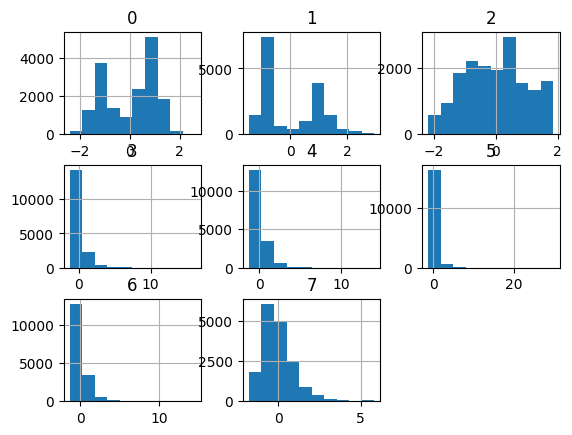

In [ ]:
#Displaying the Histogram
pd.DataFrame(X_train).hist()
# To Display without any messy output
plt.show()


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error as mse
import numpy as np

lm = LinearRegression().fit(X_train, y_train)

np.sqrt(mse(lm.predict(X_train), y_train)),np.sqrt(mse(lm.predict(X_val), y_val))



(np.float64(69458.78759326927), np.float64(71448.07245899494))

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=10).fit(X_train, y_train)

np.sqrt(mse(knn.predict(X_train), y_train)),np.sqrt(mse(knn.predict(X_val), y_val))

(np.float64(54971.713091982274), np.float64(64062.81543653896))

In [ ]:
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(max_depth=3).fit(X_train, y_train)

np.sqrt(mse(tree.predict(X_train), y_train)),np.sqrt(mse(tree.predict(X_val), y_val))

(np.float64(81965.32196989546), np.float64(83459.28850774029))

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(max_depth=10).fit(X_train, y_train)

np.sqrt(mse(rf.predict(X_train), y_train)),np.sqrt(mse(rf.predict(X_val), y_val))

(np.float64(42443.57602656433), np.float64(56543.37161564628))

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor().fit(X_train, y_train)

np.sqrt(mse(gb.predict(X_train), y_train)),np.sqrt(mse(gb.predict(X_val), y_val))

(np.float64(52170.029726880035), np.float64(57382.813401421605))